<hr style="border:2px solid #0281c9"> </hr>

<img align="left" alt="ESO Logo" src="http://archive.eso.org/i/esologo.png">  

<div align="center">
  <h1 style="color: #0281c9; font-weight: bold;">ESO Science Archive</h1> 
  <h2 style="color: #0281c9; font-weight: bold;">Jupyter Notebooks</h2>
</div>

<hr style="border:2px solid #0281c9"> </hr>

# **Link Catalogue Selections to ESO Spectroscopic Observations**

This notebook demonstrates how to start from physical parameters in an ESO catalogue, select a scientifically interesting subset of sources, and then search the ESO Science Archive for public reduced spectra at the corresponding sky positions.

The workflow has four main steps:

- discover the relevant `GAIAESO` catalogue table and inspect its metadata
- retrieve stellar parameters from the catalogue and select metal-poor stars
- use the catalogue positions as input to Phase 3 spectral-product queries
- download one matched spectrum and make a quick-look Halpha plot

---

**Authors**: Emanuele Paolo Farina & Ashley Thomas Barnes

<hr style="border:2px solid #0281c9"> </hr>

# **Importing and basic usage of astroquery.eso**

In [1]:
import astroquery # import astroquery
print(f"astroquery version: {astroquery.__version__}") # check the version of astroquery

astroquery version: 0.4.12.dev505+gf2a77a615.d20260427


In [2]:
from astroquery.eso import Eso # import the ESO module from astroquery

from astropy.coordinates import SkyCoord # sky coordinates
from astropy.io import fits # FITS file handling
from astropy.table import Table, vstack # astropy tables
from astropy.time import Time # observation-release date handling
import astropy.constants as const # physical constants
import astropy.units as u # units
from collections import Counter # compact summaries
import matplotlib.pyplot as plt # plotting
import numpy as np # numerical tools
from pathlib import Path # filesystem paths

In [3]:
eso = Eso() # create an instance of the ESO class

# **Discover the GAIA-ESO catalogue table**

The catalogue TAP metadata tables let us find which published tables belong to the `GAIAESO` collection. Here we keep the table metadata visible so that the selected catalogue can be traced back to its release documentation.

In [4]:
query = """
        SELECT collection, title, version, table_name, rel_descr_url
        FROM TAP_SCHEMA.tables
        WHERE collection = 'GAIAESO'
        ORDER BY version DESC, table_name
        """

gaiaeso_tables = eso.query_tap(query, tap_endpoint="tap_cat")
gaiaeso_tables

collection,title,version,table_name,rel_descr_url
object,object,int32,object,object
GAIAESO,Gaia-ESO spectroscopic survey,4,GES_DR5_1_V1,http://www.eso.org/rm/api/v1/public/releaseDescriptions/210
GAIAESO,Gaia-ESO spectroscopic survey,3,GES_DR5,http://www.eso.org/rm/api/v1/public/releaseDescriptions/191
GAIAESO,Gaia-ESO spectroscopic survey,2,GES_iDR4_PIII2016_Catalogue_v3_fits_V2,http://www.eso.org/rm/api/v1/public/releaseDescriptions/91
GAIAESO,GAIAESO catalogue of radial velocities,1,GES_2021_VRAD,http://www.eso.org/rm/api/v1/public/releaseDescriptions/186


For this example we use the most recent Gaia-ESO DR5.1 table (see http://www.eso.org/rm/api/v1/public/releaseDescriptions/210).

In [5]:
table_gaiaeso = "GES_DR5_1_V1"

# **Identify the physical-parameter columns via UCDs**

Column names differ across catalogues, so rather than assuming names like `LOG_G` or `LOGG`, we search `TAP_SCHEMA.columns` for the relevant UCDs:

- `meta.id` for the source identifier
- `pos.eq.ra` and `pos.eq.dec` for right ascension and declination
- `spect.dopplerVeloc.opt;meta.main` for radial velocity
- `phys.temperature.effective` for effective temperature
- `phys.gravity` for surface gravity
- `phys.abund.Fe` for iron abundance (metallicity)

In [6]:
ucds = ["meta.id;meta.main", 
        "pos.eq.ra;meta.main",
        "pos.eq.dec;meta.main",
        "spect.dopplerVeloc.opt;meta.main",
        "phys.temperature.effective", 
        "phys.gravity", 
        "phys.abund.Fe"]

query = """
    SELECT t.collection, c.table_name, c.column_name, c.ucd, c.unit
    FROM TAP_SCHEMA.tables AS t
    JOIN TAP_SCHEMA.columns AS c ON t.table_name = c.table_name
    WHERE t.table_name = '{}'
    AND c.ucd IN {}
    ORDER BY collection
    """.format(table_gaiaeso, tuple(ucds))

parameter_columns = eso.query_tap(query, tap_endpoint="tap_cat")
parameter_columns

collection,table_name,column_name,ucd,unit
object,object,object,object,object
GAIAESO,GES_DR5_1_V1,FEH,phys.abund.Fe,dex
GAIAESO,GES_DR5_1_V1,LOGG,phys.gravity,log(cm/s**2)
GAIAESO,GES_DR5_1_V1,DECLINATION,pos.eq.dec;meta.main,deg
GAIAESO,GES_DR5_1_V1,VRAD,spect.dopplerVeloc.opt;meta.main,km/s
GAIAESO,GES_DR5_1_V1,OBJECT,meta.id;meta.main,
GAIAESO,GES_DR5_1_V1,RA,pos.eq.ra;meta.main,deg
GAIAESO,GES_DR5_1_V1,TEFF,phys.temperature.effective,K


# **Retrieve metal-poor stars from the catalogue**

We now retrieve only the columns needed for the source selection. 

In [7]:
eso.ROW_LIMIT = None # retrieve the full selected-column table

gaiaeso = eso.query_catalog(
                        catalog=table_gaiaeso,
                        columns=parameter_columns["column_name"].tolist(),
                        )

gaiaeso[:3]

FEH,LOGG,DECLINATION,VRAD,OBJECT,RA,TEFF
dex,log(cm/s**2),deg,km / s,,deg,K
float32,float32,float64,float32,object,float64,float32
-0.43,1.87,-37.98272222222158,-41.23,17554609-3758578,268.94204166666213,4248.0
-1.18,2.28,-37.728749999999366,-25.13,17554664-3743435,268.94433333332887,4695.0
0.31,2.72,-37.737194444443816,-194.17,17554910-3744139,268.95458333332886,4621.0


In [8]:
METAL_LIMIT = -2.5 # dex
gaiaeso_metal_poor = gaiaeso[gaiaeso["FEH"] < METAL_LIMIT]

# **Visualise the catalogue selection**

A quick parameter-space plot is a useful check before moving from catalogue rows to archive observations. The background points show the catalogue rows with finite parameters, while the highlighted points show the metal-poor subset that will be used for positional searches.

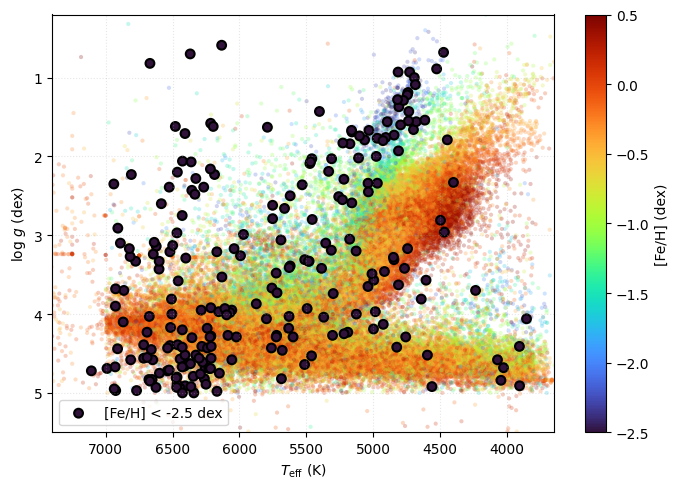

In [9]:
Path('figures').mkdir(exist_ok=True)

fig, ax = plt.subplots(figsize=(7, 5))

background = ax.scatter(
    gaiaeso["TEFF"],
    gaiaeso["LOGG"],
    c=gaiaeso["FEH"],
    cmap='turbo',
    vmin=-2.5,
    vmax=0.5,
    marker='.',
    alpha=0.25,
    linewidths=0,
)

ax.scatter(
    gaiaeso_metal_poor["TEFF"],
    gaiaeso_metal_poor["LOGG"],
    c=gaiaeso_metal_poor["FEH"],
    cmap='turbo',
    vmin=-2.5,
    vmax=0.5,
    s=40,
    edgecolor='black',
    linewidth=1.5,
    label=fr'[Fe/H] < {METAL_LIMIT} dex',
)

ax.set_xlabel(r'$T_{\mathrm{eff}}$ (K)')
ax.set_ylabel(r'$\log\,g$ (dex)')
ax.set_xlim(7400, 3650)
ax.set_ylim(5.5, 0.2)
ax.grid(True, ls=':', alpha=0.3)
ax.legend(loc='lower left')

# make dummy scatter for the colorbar
background_ = ax.scatter(
    [], [],
    c=[],
    cmap='turbo',
    vmin=-2.5,
    vmax=0.5,
    marker='.',
    alpha=0.25,
    linewidths=0,
)
background_.set_alpha(1.0)

cbar = fig.colorbar(background_, ax=ax)
cbar.set_label(r'[Fe/H] (dex)')

fig.tight_layout()
fig.savefig('figures/gaiaeso_metal_poor_parameter_space.png', dpi=300, bbox_inches='tight')

# **Query public spectra at the catalogue positions**

The catalogue gives precise positions for the selected stars. We can use those positions as input to `query_surveys()`, which searches public Phase 3 products in the observations archive.

The helper function `query_public_halpha_spectra_for_row` below applies column_filters to query for spectra that cover the Halpha wavelength (making use of `em_min` and `em_max`). The default search radius is intentionally small, because catalogue-to-observation matching should normally begin conservatively to limit false matches and then be widened only when justified by the science case or the source environment.

In [10]:
def row_float(row, column_name):
    """Return one row value as float, using NaN for masked catalogue values."""
    value = row[column_name]
    return np.nan if np.ma.is_masked(value) else float(value)


def query_public_halpha_spectra_for_row(row, radius=5 * u.arcsec):
    """Query public Phase 3 spectra covering H-alpha for one catalogue row."""
    coord = SkyCoord(
        ra=row_float(row, 'RA') * u.deg,
        dec=row_float(row, 'DECLINATION') * u.deg,
        frame='icrs',
    )

    now = Time.now().isot
    h_alpha_m = (6562.793 * u.Angstrom).to_value(u.m)

    result = eso.query_surveys(
        column_filters={
            'dataproduct_type': 'spectrum',
            'em_min': f'< {h_alpha_m}',
            'em_max': f'> {h_alpha_m}',
            'obs_release_date': f"<= '{now}'",
        },
        cone_ra=coord.ra.deg,
        cone_dec=coord.dec.deg,
        cone_radius=radius.to_value(u.deg),
    )

    if result is None or len(result) == 0:
        return None

    result['catalog_object'] = [str(row['OBJECT'])] * len(result)
    result['catalog_ra'] = [row_float(row, 'RA')] * len(result)
    result['catalog_dec'] = [row_float(row, 'DECLINATION')] * len(result)
    result['catalog_feh'] = [row_float(row, 'FEH')] * len(result)
    result['catalog_vrad'] = [row_float(row, 'VRAD')] * len(result)

    return result

For a quick notebook run we start with the first few metal-poor stars. Increase `max_targets` or set `query_rows = gaiaeso_metal_poor` to search the full selected catalogue subset.

In [11]:
max_targets = 10
query_rows = gaiaeso_metal_poor[:max_targets]

spectral_match_tables = []
for row in query_rows:
    try:
        result = query_public_halpha_spectra_for_row(row)
    except Exception as exc:
        print(f"{row['OBJECT']}: query failed ({exc})")
        continue

    if result is not None:
        spectral_match_tables.append(result)

matched_spectra = (
    vstack(spectral_match_tables, metadata_conflicts='silent')
    if spectral_match_tables
    else Table()
)

print(f"Matched spectral products: {len(matched_spectra)}")

display_columns = [
    'catalog_object', 'catalog_feh', 'catalog_vrad', 'target_name',
    'instrument_name', 'obs_collection', 'proposal_id', 'dp_id',
    'em_min', 'em_max', 'snr', 'access_estsize',
]

matched_spectra[display_columns][:3] if len(matched_spectra) else matched_spectra

Matched spectral products: 30


catalog_object,catalog_feh,catalog_vrad,target_name,instrument_name,obs_collection,proposal_id,dp_id,em_min,em_max,snr,access_estsize
,,,,,,,,m,m,,kbyte
str16,float64,float64,object,object,object,object,object,float64,float64,float64,int64
17545552-3803393,-3.380000114440918,23.010000228881836,17545552-3803393,UVES,GAIAESO,193.B-0936(C),ADP.2020-12-07T15:34:40.248,5.822e-07,6.83091e-07,43.1,967
19103087-5958439,-3.190000057220459,-19.079999923706055,19103087-5958439,UVES,GAIAESO,193.D-0232(B),ADP.2020-12-07T15:34:21.163,5.822e-07,6.83091e-07,17.0,967
08095042-4657080,-3.319999933242798,46.86000061035156,08095042-4657080,UVES,GAIAESO,188.B-3002(A),ADP.2020-12-07T15:34:31.417,5.822e-07,6.83091e-07,127.1,967


The matched products can be summarised by catalogue source and instrument. This is often the first useful triage step before deciding which products to download.

In [12]:
if len(matched_spectra):
    counts = Counter(
        (str(row['catalog_object']), str(row['instrument_name']))
        for row in matched_spectra
    )
    summary_rows = [
        (catalog_object, instrument_name, n_products)
        for (catalog_object, instrument_name), n_products in counts.items()
    ]
    match_summary = Table(
        rows=summary_rows,
        names=['catalog_object', 'instrument_name', 'n_products'],
    )
    match_summary.sort(['catalog_object', 'instrument_name'])
else:
    match_summary = Table(
        names=['catalog_object', 'instrument_name', 'n_products'],
        dtype=['U32', 'U32', 'i4'],
    )

match_summary

catalog_object,instrument_name,n_products
str16,str8,int64
05265916-0221383,UVES,9
05265916-0221383,XSHOOTER,4
08095042-4657080,UVES,1
14023168+0941090,ESPRESSO,2
14023168+0941090,GIRAFFE,8
14023168+0941090,UVES,4
17545552-3803393,UVES,1
19103087-5958439,UVES,1


# **Inspect a well-known metal-poor star**

The same pattern can be used for an individual object when a wider matching radius is appropriate. 

Here we use the Gaia-ESO catalogue entry for HD 140283, a bright metal-poor (Fe/H = -2.3) star with multiple public ESO spectra.

In [13]:
hd140283_catalogue_id = '15430220-1056042'
object_names = np.asarray(gaiaeso['OBJECT']).astype(str)

hd140283_rows = gaiaeso[object_names == hd140283_catalogue_id]
hd140283_rows['OBJECT', 'RA', 'DECLINATION', 'VRAD', 'TEFF', 'LOGG', 'FEH']

OBJECT,RA,DECLINATION,VRAD,TEFF,LOGG,FEH
,deg,deg,km / s,K,log(cm/s**2),dex
object,float64,float64,float32,float32,float32,float32
15430220-1056042,235.75916666666302,-10.934499999999801,-170.39,5718.0,3.71,-2.27


In [14]:
hd140283_spectra = query_public_halpha_spectra_for_row(hd140283_rows[0], radius=30*u.arcsec)

preferred_collections = ['GAIAESO', 'GIRAFFE', 'UVES', 'XSL']
if hd140283_spectra is not None and len(hd140283_spectra):
    collection_names = np.asarray(hd140283_spectra['obs_collection']).astype(str)
    keep = np.isin(collection_names, preferred_collections)
    hd140283_spectra = hd140283_spectra[keep]
    hd140283_spectra.sort(['instrument_name', 'dp_id'])
else:
    hd140283_spectra = Table()

hd140283_spectra[:3]

target_name,s_ra,s_dec,dp_id,proposal_id,abmaglim,access_estsize,access_format,access_url,bib_reference,calib_level,dataproduct_subtype,dataproduct_type,em_max,em_min,em_res_power,em_xel,facility_name,filter,gal_lat,gal_lon,instrument_name,is_solar,last_mod_date,multi_ob,n_obs,o_calib_status,o_ucd,obs_collection,obs_creator_did,obs_creator_name,obs_id,obs_publisher_did,obs_release_date,obs_title,obstech,p3orig,pol_states,pol_xel,preview_html,publication_date,release_description,s_fov,s_pixel_scale,s_region,s_resolution,s_xel1,s_xel2,snr,strehl,t_exptime,t_max,t_min,t_resolution,t_xel,catalog_object,catalog_ra,catalog_dec,catalog_feh,catalog_vrad
,deg,deg,,,mag,kbyte,,,,,,,m,m,,,,,deg,deg,,,,,,,,,,,,,,,,,,,,,,deg,arcsec,,arcsec,,,,,s,d,d,s,,,,,,
object,float64,float64,object,object,float64,int64,object,object,object,int32,object,object,float64,float64,float64,int64,object,object,float64,float64,object,int16,object,object,int32,object,object,object,object,object,object,object,object,object,object,object,object,int64,object,object,object,float64,float64,object,float64,int64,int64,float64,float64,float64,float64,float64,float64,int64,str16,float64,float64,float64,float64
15430220-1056042,235.758999,-10.934527,ADP.2017-05-11T07:30:20.268,188.B-3002(E),--,132,application/x-votable+xml;content=datalink,http://archive.eso.org/datalink/links?ID=ivo://eso.org/ID?ADP.2017-05-11T07:30:20.268,,2,flux-not-calibrated,spectrum,6.816000000000001e-07,6.444e-07,17000.0,7441,ESO-VLT-U2,,33.616282,356.308727,GIRAFFE,0,2026-02-17T12:17:06.380Z,S,1,uncalibrated,,GAIAESO,ivo://eso.org/origfile?gir3_15430220-1056042_H665.0_10_iDR5.fits,"GILMORE, GERARD",200231298,ivo://eso.org/ID?ADP.2017-05-11T07:30:20.268,2017-05-11T14:07:29.030Z,GES Giraffe spectrum for 15430220-1056042 in HR15,MOS,EDP,,--,https://archive.eso.org/dataset/ADP.2017-05-11T07:30:20.268,2017-05-12T07:16:59Z,http://www.eso.org/rm/api/v1/public/releaseDescriptions/92,0.00033305,--,POSITION J2000 235.75899900000002 -10.934527,--,--,--,116.9,--,5.103,56046.324508,56046.32444893,5.103648,--,15430220-1056042,235.75916666666302,-10.934499999999801,-2.2699999809265137,-170.38999938964844
15430220-1056042,235.758999,-10.934527,ADP.2017-05-11T07:30:20.270,188.B-3002(E),--,132,application/x-votable+xml;content=datalink,http://archive.eso.org/datalink/links?ID=ivo://eso.org/ID?ADP.2017-05-11T07:30:20.270,,2,flux-not-calibrated,spectrum,6.816000000000001e-07,6.444e-07,17000.0,7441,ESO-VLT-U2,,33.616282,356.308727,GIRAFFE,0,2026-02-17T12:17:09.153Z,S,1,uncalibrated,,GAIAESO,ivo://eso.org/origfile?gir3_15430220-1056042_H665.0_11_iDR5.fits,"GILMORE, GERARD",200231298,ivo://eso.org/ID?ADP.2017-05-11T07:30:20.270,2017-05-11T14:07:29.407Z,GES Giraffe spectrum for 15430220-1056042 in HR15,MOS,EDP,,--,https://archive.eso.org/dataset/ADP.2017-05-11T07:30:20.270,2017-05-12T07:16:59Z,http://www.eso.org/rm/api/v1/public/releaseDescriptions/92,0.00033305,--,POSITION J2000 235.75899900000002 -10.934527,--,--,--,114.9,--,5.103,56046.32518246,56046.3251234,5.102784,--,15430220-1056042,235.75916666666302,-10.934499999999801,-2.2699999809265137,-170.38999938964844
15430220-1056042,235.758999,-10.934527,ADP.2017-05-11T07:30:20.272,188.B-3002(F),--,132,application/x-votable+xml;content=datalink,http://archive.eso.org/datalink/links?ID=ivo://eso.org/ID?ADP.2017-05-11T07:30:20.272,,2,flux-not-calibrated,spectrum,6.816000000000001e-07,6.444e-07,17000.0,7441,ESO-VLT-U2,,33.616282,356.308727,GIRAFFE,0,2026-02-17T12:17:13.410Z,S,1,uncalibrated,,GAIAESO,ivo://eso.org/origfile?gir3_15430220-1056042_H665.0_12_iDR5.fits,"GILMORE, GERARD",200232664,ivo://eso.org/ID?ADP.2017-05-11T07:30:20.272,2017-05-11T14:07:29.030Z,GES Giraffe spectrum for 15430220-1056042 in HR15,MOS,EDP,,--,https://archive.eso.org/dataset/ADP.2017-05-11T07:30:20.272,2017-05-12T07:16:59Z,http://www.eso.org/rm/api/v1/public/releaseDescriptions/92,0.00033305,--,POSITION J2000 235.75899900000002 -10.934527,--,--,--,96.4,--,10.002,56076.25742514,56076.25730937,10.

# **Download the matched spectrum**

The returned table contains the `dp_id` identifiers needed by `retrieve_data()`. 

In [15]:
Path('data').mkdir(exist_ok=True)
data_files = eso.retrieve_data(hd140283_spectra['dp_id'], destination='./data/')

INFO: Downloading datasets ... [astroquery.eso.core]
INFO: Downloading 83 files ... [astroquery.eso.core]
INFO: Downloading file 1/83 https://dataportal.eso.org/dataPortal/file/ADP.2017-05-11T07:30:20.268 to /Users/abarnes/Library/CloudStorage/Dropbox/GitHub/astroquery_examples_eso/examples/advanced/data [astroquery.eso.core]
INFO: Found cached file /Users/abarnes/Library/CloudStorage/Dropbox/GitHub/astroquery_examples_eso/examples/advanced/data/ADP.2017-05-11T07:30:20.268.fits [astroquery.eso.core]
INFO: Downloading file 2/83 https://dataportal.eso.org/dataPortal/file/ADP.2017-05-11T07:30:20.270 to /Users/abarnes/Library/CloudStorage/Dropbox/GitHub/astroquery_examples_eso/examples/advanced/data [astroquery.eso.core]
INFO: Found cached file /Users/abarnes/Library/CloudStorage/Dropbox/GitHub/astroquery_examples_eso/examples/advanced/data/ADP.2017-05-11T07:30:20.270.fits [astroquery.eso.core]
INFO: Downloading file 3/83 https://dataportal.eso.org/dataPortal/file/ADP.2017-05-11T07:30:20.2

# **Make a quick-look Halpha plot**

As a final check, we verify that the downloaded spectrum covers the expected wavelength range and produce a simple normalised view around the Halpha line. This provides a quick visual sanity check of both the data quality and the wavelength calibration.

To support this, we define a small helper function that extracts and standardises the 1D spectrum from the FITS file.

At a high level, this routine:

- identifies the table extension containing the spectral data  
- retrieves the wavelength, flux, and (if available) uncertainty columns, allowing for different naming conventions across instruments  
- applies basic unit conversions (e.g. nm → Å)  
- applies wavelength corrections, including barycentric and (if present) source-frame corrections  
- applies instrument-specific flux scaling where required  
- returns clean NumPy arrays ready for analysis  

This ensures that spectra from different ESO instruments can be handled in a consistent way, despite differences in formatting and metadata.

**Note:** This section optionally uses the `PyAstronomy` package for barycentric corrections, which is not a dependency of `astroquery`.

In [16]:
from PyAstronomy import pyasl # PyAstronomy - used for Baricentric correction if not in header

In [17]:
def get_fits_column(data, possible_names):
    """Return the first matching FITS table column from a list of possible names."""
    name_map = {name.upper(): name for name in data.names}

    for possible_name in possible_names:
        matched_name = name_map.get(possible_name.upper())
        if matched_name is not None:
            return np.asarray(data[matched_name]).squeeze()

    raise KeyError(f"None of the columns {possible_names} were found")


def extract_1d_spectrum(filename, verbose=False):
    """Extract wavelength, flux, error, and instrument name from a 1D ESO spectrum."""
    with fits.open(filename) as hdul:
        primary = hdul[0].header
        spectrum_hdu = None

        for hdu in hdul[1:]:
            names = getattr(getattr(hdu, "data", None), "names", None)
            if names is not None and "WAVE" in [name.upper() for name in names]:
                spectrum_hdu = hdu
                break

        if spectrum_hdu is None:
            raise ValueError(f"No spectral table extension found in {filename}")

        data = spectrum_hdu.data
        header = spectrum_hdu.header

        instrument = primary.get("INSTRUME", "UNKNOWN")
        specsys = primary.get("SPECSYS", "")

        # Wavelength correction
        wave_corr = 10.0 if header.get("TUNIT1", "").lower() == "nm" else 1.0

        barycorr = primary.get("HIERARCH ESO QC VRAD BARYCOR")

        if barycorr is not None:
            wave_corr *= 1.0 + barycorr / const.c.to_value("km/s")

            if verbose:
                print(f"Barycentric correction for {instrument}: {barycorr}")

        elif specsys == "TOPOCENT":
            try:
                ra = primary["RA"]
                dec = primary["DEC"]
                mjd = primary["MJD-OBS"]

                _, barycorr = pyasl.baryCorr(mjd, ra, dec)
                wave_corr *= 1.0 + barycorr / const.c.to_value("km/s")

                if verbose:
                    print(
                        f"Barycentric correction for {instrument}: "
                        f"{barycorr} using PyAstronomy"
                    )

            except Exception as exc:
                if verbose:
                    print(f"No barycentric correction applied for {instrument}: {exc}")

        if specsys == "SOURCE":
            sourcecorr = primary.get("REST_VAL")

            if sourcecorr is not None:
                wave_corr *= 1.0 + sourcecorr / const.c.to_value("km/s")

                if verbose:
                    print(f"Source correction for {instrument}: {sourcecorr}")

        # Flux correction
        flux_corr = {
            "MUSE": 1.0,
            "XSHOOTER": 1.0,
            "UVES": 1e-16,
            "GIRAFFE": 1.0,
        }.get(instrument, 1.0)

        if instrument not in {"MUSE", "XSHOOTER", "UVES", "GIRAFFE"} and verbose:
            print(f"Unknown instrument: {instrument}; no flux scaling applied")

        wave = get_fits_column(data, ["WAVE", "WAVELENGTH"]) * wave_corr
        flux = get_fits_column(data, ["FLUX", "FLUX_REDUCED"]) * flux_corr

        try:
            flux_err = get_fits_column(
                data,
                ["ERR", "ERROR", "FLUXERR", "ERR_REDUCED"],
            ) * flux_corr
        except KeyError:
            flux_err = np.full_like(flux, np.nan, dtype=float)

        wave = np.asarray(wave, dtype=float)
        flux = np.asarray(flux, dtype=float)
        flux_err = np.asarray(flux_err, dtype=float)

        if verbose:
            print(f"Content of the {instrument} spectrum:\n{spectrum_hdu.columns}\n")

    flux[flux == 0] = np.nan
    flux_err[flux_err == 0] = np.nan

    return wave, flux, flux_err, instrument

Plot the data, zooming in on the Halpha line and applying a simple normalisation. 

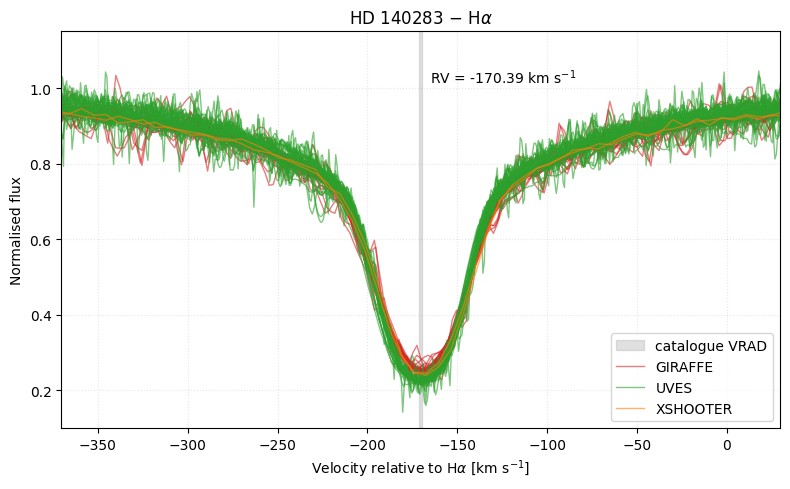

In [18]:
if not isinstance(data_files, (list, tuple)):
    data_files = [data_files]

h_alpha = 6562.793
radial_velocity = float(hd140283_rows["VRAD"][0])

instrument_styles = {
    "XSHOOTER": {"color": "C1", "shift": 5},
    "UVES": {"color": "C2", "shift": 0},
    "GIRAFFE": {"color": "C3", "shift": 0},
}

fig, ax = plt.subplots(figsize=(8, 5))

ax.axvspan(
    radial_velocity - 0.8,
    radial_velocity + 0.8,
    color="0.7",
    alpha=0.4,
    label="catalogue VRAD",
)

for data_file in data_files:
    wave, flux, flux_err, instrument = extract_1d_spectrum(Path(data_file))

    velocity = (wave / h_alpha - 1.0) * const.c.to_value("km/s")

    continuum_mask = (
        ((wave > 6550) & (wave < 6555)) |
        ((wave > 6575) & (wave < 6585))
    )

    normalisation = np.nanmedian(flux[continuum_mask])
    flux_norm = flux / normalisation

    style = instrument_styles.get(instrument, {"color": "C4", "shift": 0})
    velocity_plot = velocity - style["shift"]

    ax.plot(
        velocity_plot,
        flux_norm,
        color=style["color"],
        lw=1.0,
        alpha=0.6,
        label=instrument,
    )

ax.set_xlim(radial_velocity - 200, radial_velocity + 200)
ax.set_ylim(0.1, 1.15)
ax.set_xlabel(r"Velocity relative to H$\alpha$ [km s$^{-1}$]")
ax.set_ylabel("Normalised flux")
ax.set_title(r"HD 140283 $-$ H$\alpha$")

ax.text(
    radial_velocity + 5,
    1.03,
    rf"RV = {radial_velocity:.2f} km s$^{{-1}}$",
    ha="left",
    va="center",
)

handles, labels = ax.get_legend_handles_labels()
unique = {
    label: handle
    for handle, label in zip(handles, labels)
}
ax.legend(unique.values(), unique.keys(), loc="lower right")

ax.grid(True, ls=":", alpha=0.3)

fig.tight_layout()
fig.savefig(
    "./figures/HD140283_halpha_catalogue_link.png",
    dpi=300,
    bbox_inches="tight",
)

<hr style="border:2px solid #0281c9"> </hr>